# Gaseous Absorption - Exploring HITRAN

In [4]:
import os
# Uncomment and adjust the following lines
# if ARTS_DATA_PATH is not set as environment variable
os.environ["ARTS_DATA_PATH"] = "/Users/wgblumbe/Code/rttools/arts_catalogs/arts-cat-data-snapshot-arts-2.5.8/"
import pyarts
import matplotlib.pyplot as plt
import numpy as np
import re
from line_module import getLines

def tag2tex(tag):
    """Replace all numbers in a species tag with LaTeX subscripts."""
    return re.sub("([a-zA-Z]+)([0-9]+)", r"\1$_{\2}$", tag)


## Viewing the lines for a specific molecular isotope

The variable `species` is a string that corresponds to a particular molecular isotope within the line database.

We have to tell the radiative transfer model (that reads in each of the spectral lines from the line database) what spectral regions we want.  The ARTS model here uses frequency (Hz) to denote the spectral region we care about.

`fmin` - the minimum frequency

`fmax` - the maximum frequency

`fnum` - the number of frequencies in between `fmin` and `fmax`

This next block of code loops through the spectral line database for the selected molecule and pulls out the line locations (in Hz) and the line strength.

**Some possible molecules to explore:**

* O2-66
* O3
* N2O
* CO2
* H2O

In [23]:
species = "O2-66"
fmin=10e9 # Hz
fmax=10000e9 # Hz
fnum=100000

line_location, line_strength = getLines(species, fmin, fmax, fnum)


Lines meta-data:
	Species identity:
		Species: O2-66
		Identity: O2-66 ElecStateLabel B X Lambda 0 0 S 0 1 v 19 0
	The lines will be cut-off 0.01 Hz from the line center + D0.
	The lines are considered as in pure LTE.
	Simple frequency scaling of the far-wings will be applied, i.e. F ~ (f / f0) * ((1 - exp(- hf / kT)) / (1 - exp(- hf0 / kT)))
	The line shape type is the Voigt profile.
	These lines are not mirrored at 0 Hz.
	The reference temperature for all line parameters is 296 K.
	If applicable, there is no line mixing limit.
	No line data is available.



Now let's plot the line locations for this spectral region.

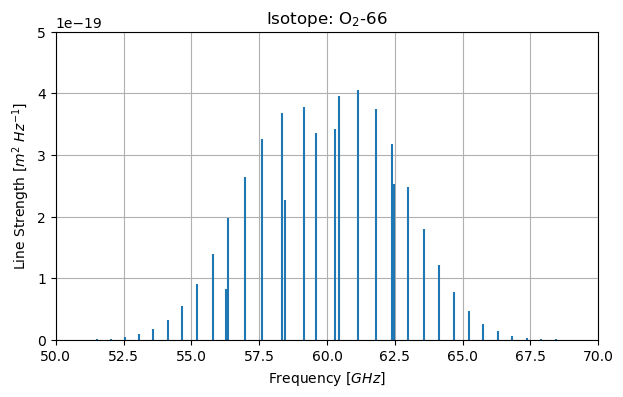

In [24]:
def hz2Ghz(freq):
    return freq/1e9

ghz_freq = hz2Ghz(line_location) # Converts Hz to GHz

plt.figure(figsize=(7,4))
plt.vlines(ghz_freq, ymin=0, ymax=line_strength)
plt.xlim(50,70) # Limits in GHz
plt.ylim(0,0.5e-18)
plt.ylabel("Line Strength [$m^2\ Hz^{-1}$]")
plt.xlabel("Frequency [$GHz$]")
plt.title(f"Isotope: {tag2tex(species)}")
plt.grid()
plt.show()